<a href="https://colab.research.google.com/github/addielee-here/2025-aiffel-projects/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 프로젝트 개요
---
### 프로젝트명
신용카드 이상 감지 모델을 위한 데이터 전처리 및 학습, 평가

### 목표
- 신용카드 이상 감지 모델을 위한 탐색적 데이터 분석 및 전처리
- 분류 모델(XG Boost 알고리즘)을 사용한 베이스라인 모델 훈련 및 성능 검증
- 예측 성능 개선을 위한 피처 엔지니어링

## STEP 1. 탐색적 데이터 분석 및 전처리
---
- 금융 거래 특성상, 정상 거래가 압도적으로 많고 사기 거래는 매우 적으므로 클래스 불균형 문제가 발생한다.  
  - 이를 해결하기위해, 본 프로젝트에서는 불균형 데이터에 적합한 지표인 F1 Score를 선택해 모델의 예측 성능을 평가할 예정이다.
  - 또한, 소수 클래스에 더 높은 가중치를 부여하는 알고리즘적 접근 방식을 선택할 예정이다.
  
- XG Boost 알고리즘을 사용하기위해 다음과 같은 전처리를 진행한다.
  - 범주형 데이터 원-핫 인코딩
  - 결측치, 이상치 확인 및 처리
  - Feature Engineering
  - 시계열 time-series split (훈련/ 검증 데이터 분리)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/sample_data/fraud.csv')

In [3]:
# 데이터 구조 탐색 - 레코드 수, 피쳐 수, 데이터 타입 확인
df.head(10)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100755 entries, 0 to 100754
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  100755 non-null  object 
 1   cc_num                 100755 non-null  int64  
 2   merchant               100755 non-null  object 
 3   category               100755 non-null  object 
 4   amt                    100755 non-null  float64
 5   first                  100755 non-null  object 
 6   last                   100755 non-null  object 
 7   gender                 100755 non-null  object 
 8   street                 100755 non-null  object 
 9   city                   100755 non-null  object 
 10  state                  100755 non-null  object 
 11  zip                    100755 non-null  int64  
 12  lat                    100755 non-null  float64
 13  long                   100755 non-null  float64
 14  city_pop               100755 non-nu

## 정리
레코드 수는 총 491134개이며, 피처는 총 21개이다.
대부분의 피처는 범주형 데이터이며, 몇몇 피처는 숫자형 데이터이다.

### 피처별 의미
- trans_date_trans_time (object): 거래가 발생한 날짜와 시간
- cc_num (int64): 고객의 신용카드 번호
- merchant (object): 거래가 발생한 상점 이름
- category (object): 상점(merchant)가 해당하는 카테고리
- amt (float64): 거래 금액
- first (object): 고객의 이름
- last (object): 고객의 성
- gender (object): 고객의 성별
- street (object): 고객 주소 도로명
- city (object): 고객 주소 도시명
- state (object): 고객 주소의 주(State) 이름
- zip (object): 고객의 우편번호
- lat (float64): 고객의 위도
- long (float64): 고객의 경도
- city_pop (int64): 고객이 거주하는 도시의 인구 수
- job (object): 고객의 직업
- dob (object): 고객 생년월일
- trans_num (object): 거래에 대한 unique transaction identifier
- unix_time (int64): 거래 시간을 Unix Time으로 표현한 값
- merch_lat (float64): 상점의 위도
- merch_long (float64): 상점의 경도
- is_fraud (int64): Fraud 여부

이중에, 이상거래 탐지를 위해서 is_fraud는 타깃(종속 변수)이 된다.  
is_fraud를 더 잘 탐지하기 위한 파생 변수를 어떤 기준에 의거해 어떤 데이터를 사용해 조합할지,  
예측에 직접적인 도움이 되지않는 불필요한 피쳐는 없는 지 먼저 확인해보자.    

### 파생 변수 생성
이상 거래의 일반적인 특징을 고려했을 때 다음과 같은 행동 패턴을 보인다:  
- 비정상적인 장소에서 발생하는 거래: 고객 거주지와 매우 먼 지역에서 결제 발생 (해외/ 타지역 등)
- 짧은 시간 내 다량의 거래: 몇 분 간격으로 여러 건의 결제 발생, 작은 금액으로 여러번 결제하다가 성공하면 큰 금액을 결제함
- 고객의 평소 거래 패턴에서 벗어난 비정상적인 금액 (지나치게 크거나, 작은 금액) 거래 발생
- 평소 잘 거래하지않던 상점 유형에서 결제 발생
- 야간 시간대 거래 발생 (새벽/야간 거래로 고객이 자고 있을 때 승인 요청)

따라서, 위치와 거리 기반, 시간 기반 이상을 탐지해야하고  
평소 거래 금액/카테고리/거래 빈도 등의 분포도를 확인할 수 있게끔  
기존 데이터를 조합해 파생 변수를 만들 필요성이 있다.


### 불필요한 컬럼 제거

first, last와 같은 피쳐는 별도의 인코딩이 필요한 범주형 데이터인데다가 고유값일 가능성이 많아 모델링 단계에서 과적합(overfitting)을 유발하거나 분석을 복잡하게 만들 수 있어,  
데이터 정제의 마지막 단계에서 제거해보는것이 좋겠다.  
street 또한 도로명이라 city/state와 달리 매우 상세한 주소를 나타내는 문자열이기에 모델에 직접 이용하기에는 부적절하다고 판단해서 제거 대상이다.  








(0.0, 500.0)

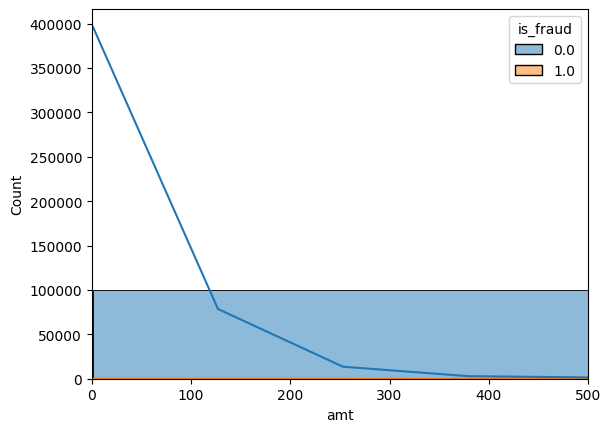

In [4]:
# 통계적 정보 확인
df.describe()

# 정상 거래 vs. 이상 거래 주요 변수 분포도 비교 (시각화) - 거래 금액
sns.histplot(data=df, x="amt", hue="is_fraud", kde=True, bins=50)
plt.xlim(0, 500)


Text(0.5, 1.0, 'Normal vs Fraud KDE with Emphasized Fraud Bandwidth')

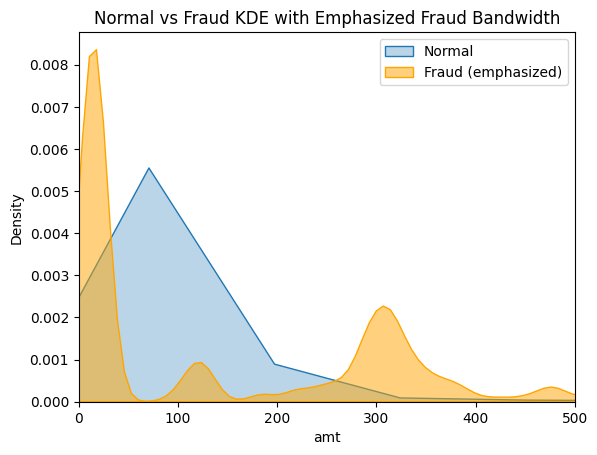

In [5]:
# 커널 밀도 그래프 - 분포 확인
sns.kdeplot(
    data=df[df["is_fraud"] == 0],
    x="amt",
    bw_adjust=1,
    fill=True,
    alpha=0.3,
    label="Normal"
)

sns.kdeplot(
    data=df[df["is_fraud"] == 1],
    x="amt",
    bw_adjust=0.1,  # fraud를 확대해서 보이게
    fill=True,
    alpha=0.5,
    color="orange",
    label="Fraud (emphasized)"
)

plt.xlim(0, 500)
plt.legend()
plt.title("Normal vs Fraud KDE with Emphasized Fraud Bandwidth")

## 정리
정상 거래 vs. 이상 거래 거래 금액 분포도를 커널 밀도 추정을 통해 비교해 본 결과,  
거래 패턴의 확연한 차이가 있었다.

그래프의 첫 시작 부분을 살펴보면 사기에 해당하는 KDE 피크가 정상보다 훨씬 높게 나타나는데, 이는 소액 테스트 결제가 매우 흔한 패턴임을 시사한다.
그래프의 중간 구간을 살펴보면 사기에 해당하는 거래가 크게 두드러지지않고 정상 거래 KDE 위주인것을 확인해볼수있다.  
그래프의 오른쪽 구간을 살펴보면 사기에 해당하는 KDE가 다시 두드러지는 모습을 보여준다.  
이는 즉, 사기범들이 소액 결제로 테스트를 시도한 후 고액 결제 시도가 해당 금액대(200~300달러)에 집중되는 패턴을 명확히 보여주고있다.

따라서, 금액의 경우 분포 차이가 매우 명확하므로 이상거래 예측을 위한 중요도에서 많은 역할을 차지한다고 볼 수 있다.

In [6]:
# 거래 시간 관련

# datetime 추출
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["hour"] = df["trans_date_trans_time"].dt.hour
df["weekday"] = df["trans_date_trans_time"].dt.weekday

<Axes: xlabel='hour', ylabel='Count'>

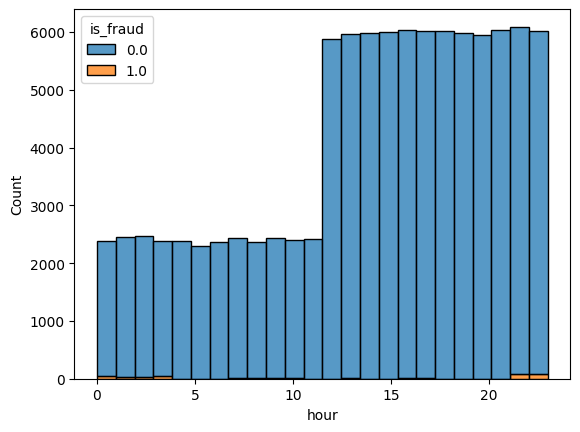

In [7]:
# 시간대별 거래 패턴 비교
sns.histplot(data=df, x='hour', hue='is_fraud', multiple='stack', bins=24)

<Axes: xlabel='weekday', ylabel='count'>

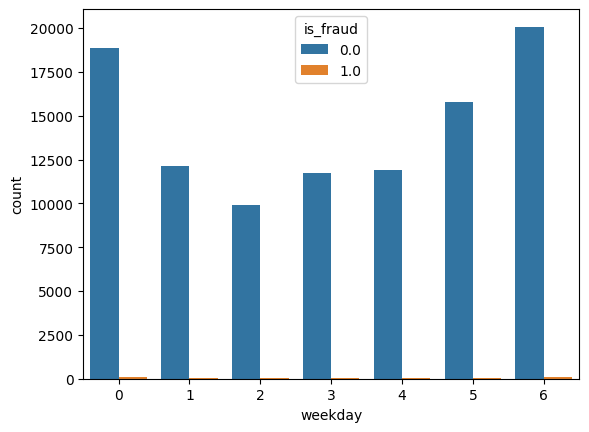

In [8]:
# 요일별 거래 패턴 비교
sns.countplot(data=df, x="weekday", hue="is_fraud")

## 정리
정상 거래 vs. 이상 거래 시간 및 요일별 분포도를 시각화를 통해 비교해 본 결과,  
시간대별 거래 패턴이 확연한 차이가 있었다.  

정상 거래와는 달리, 오전 0시~4시(새벽 시간대)와 오후 9시~11시(저녁 시간대)에 거래가 집중되는 형태를 보인다.  
거래 시간대 또한 이상 거래 예측을 위한 중요도에서 많은 비중을 차지함을 알 수 있다.


In [9]:
# 결측치 비율 확인
df.isna().mean()

,0
trans_date_trans_time,0.00000
cc_num,0.00000
merchant,0.00000
category,0.00000
amt,0.00000
first,0.00000
last,0.00000
gender,0.00000
street,0.00000
city,0.00000


In [10]:
# 이상치 확인을 위한 파생 변수 생성
'''
- 고객의 위도, 경도와 상점의 위도, 경도 비교
- 5분 기준 거래 빈도
- 고객별 최빈 거래 상점 유형 (카테고리)
- 고객별 최빈 거래 상점 유형 대비 다른 카테고리가 얼마나 많이 거래되었는지에 대한 평균과 빈도
- 거래시간대가 특정 구간에 포함되는지 (오전 0시~4시, 오후 9시~11시)
- 연령대별 평균 지출 소비금액 (하루, 일주일, 한달) 대비 고객의 소비 정도
'''

# 고객의 위도,경도와 상점의 위도,경도 차이 확인 (단위: km)

def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['dist_from_home'] = haversine_np(
    df['lat'], df['long'], df['merch_lat'], df['merch_long']
)

# 1시간 기준 거래 빈도
df['1hr_block'] = df['trans_date_trans_time'].dt.floor('h')
df['1hr_freq'] = df.groupby(['cc_num', '1hr_block'])['trans_num'].transform('count')

# 고객별 최빈 거래 상점 유형 (카테고리)
df['most_common_category'] = (
    df.groupby('cc_num')['category']
      .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# 고객별-카테고리별 거래 횟수
df['category_freq'] = df.groupby(['cc_num', 'category'])['category'].transform('count')

# 카테고리 빈도 차이
# 고객-카테고리별 카운트 테이블
cat_counts = (
    df.groupby(['cc_num', 'category'])
      .size()
      .rename('category_freq')
      .reset_index()
)

# 고객별 최빈 카테고리의 등장 횟수
max_cat_counts = (
    cat_counts.groupby('cc_num')['category_freq']
              .max()
              .rename('most_common_cat_count')
              .reset_index()
)

df = df.merge(max_cat_counts, on='cc_num', how='left')

'''
최빈 카테고리 드리프트(얼마나 벗어나는지) 정의

0에 가까울수록 익숙한 카테고리
1에 가까울수록 생소한 카테고리
'''

df['cat_drift_ratio'] = 1 - (df['category_freq'] / df['most_common_cat_count'])


# 거래시간대가 특정 구간에 포함되는지 (오전 0시~4시, 오후 9시~11시)
df['is_late_night'] = df['hour'].between(0, 4)
df['is_evening']    = df['hour'].between(21, 23)

# 평균 지출 소비금액 (하루, 일주일, 한달)
df['date'] = df['trans_date_trans_time'].dt.date
df['week'] = df['trans_date_trans_time'].dt.isocalendar().week
df['month'] = df['trans_date_trans_time'].dt.month

df['daily_avg_amt'] = df.groupby(['cc_num','date'])['amt'].transform('mean')
df['weekly_avg_amt'] = df.groupby(['cc_num','week'])['amt'].transform('mean')
df['monthly_avg_amt'] = df.groupby(['cc_num','month'])['amt'].transform('mean')

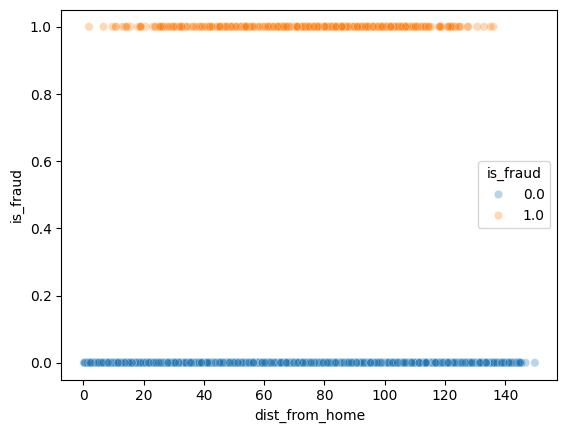

In [11]:
# 파생 변수 관계 확인, 전반적인 피쳐 특성 관계 확인 : 상관관계 분석

# 독립변수 - 파생 변수 간 scatter
sns.scatterplot(data=df, x='dist_from_home', y='is_fraud', hue='is_fraud', alpha=0.3)
plt.show()


## 정리

dist_from_home, is_fraud 간의 분포를 확인해보니 특정 구간에서 fraud 발생비율이 커지는 정보는 눈에 띄지 않았고 고른 분포를 보인다.  
즉, 거리가 멀어진다고해서 이상 거래일 확률이 증가한다는 가정은 입증되지 않는다고 보면 된다.

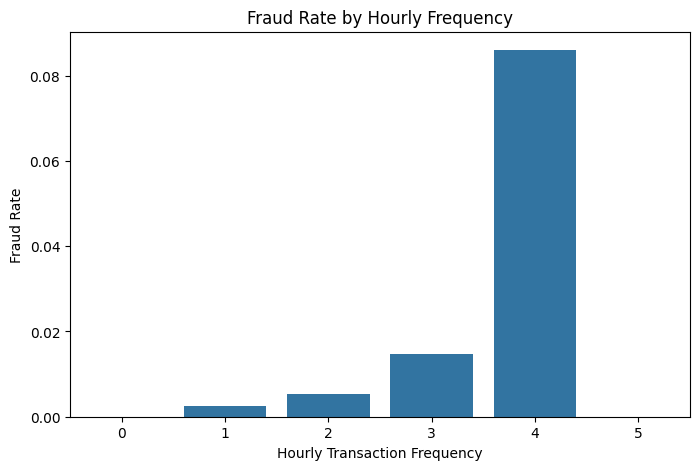

In [12]:
# 파생 변수 - 파생 변수간 scatter/kde
df[['1hr_freq', 'is_fraud']].corr(numeric_only=True)

# 파생 변수 관계 확인, 전반적인 피쳐 특성 관계 확인 : 상관관계 분석

# hourly_freq별 fraud 비율 계산
freq_fraud_rate = df.groupby('1hr_freq')['is_fraud'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=freq_fraud_rate, x='1hr_freq', y='is_fraud')
plt.title('Fraud Rate by Hourly Frequency')
plt.ylabel('Fraud Rate')
plt.xlabel('Hourly Transaction Frequency')
plt.show()

## 정리
1시간 간격의 거래 빈도와 is_fraud는 아주 미세한 양의 상관관계를 가지고있으나 0에 가깝다.  
두 속성을 합쳐 하나의 인덱스(freq_fraud_rate)를 만들고 바 그래프를 그려 확인해보면 전반적으로 1시간단위의 거래량이 높을수록 이상 거래 확률도 높아진다는것을 확인할 수 있다.  
따라서, 거래 빈도에 따른 피쳐는 freq_fraud_rate 하나로만 유지하고 모델링 시 정리하도록 하자.

## EDA 최종 정리
---

### 데이터 분포 확인
- 처음 가설중 하나였던, "거리가 멀어진다고해서 이상 거래일 확률이 증가한다"는 가정은 사실이 아니었다.
- 거의 대부분의 파생 변수가 예측에 직접적인 영향을 끼치진 못한다는 사실을 확인했다.
- 이를 위해, 추후 EDA 과정을 거듭하며 확실한 영향을 끼치는 파생 변수를 발견해야한다.

### 타겟(is_fraud)과의 상관관계 분석

`is_fraud` 열 기준으로 보면:
- daily_avg_amt : 0.28
- amt : 0.13
- weekly_avg_amt : 0.13
- is_late_night : 0.05
- is_evening : 0.03

으로, 나머지는 거의 0 근처이다.

해석하자면 일별 평균 금액이 is_fraud와의 상관계수를 따져봤을때 0.28로 가장 큰 양의 상관관계를 가지고있다.  
즉 평소에 카드로 쓰는 일 평균 금액이 높은 사람일수록 사기 거래일 확률이 조금 더 높다는 의미이다.

또한, 거래 금액과 주간 평균은 각각 0.13 정도로 양의 상관관계를 가지고있다.  
사기 거래가 대체로 금액이 크거나, 주간 평균이 높은 (많이 쓰는) 사람들에게서 더 자주 발생하는 패턴임을 시사한다.  

### 카테고리 관련, 금액 관련 파생 변수들

category_freq, cat_drift_ratio, most_common_cat_count 셋 다 강하게 연관되어있어 다중공선성 문제가 생기기 쉽고
예측에 도움이 되는 의미 있는 독립 변수가 아니므로 feature importance 결과를 보고 기여도가 낮다면 과감히 제거해주는게 좋겠다.

daily_avg_amt, weekly_avg_amt, monthly_avg_amt의 경우 daily_avg_amt, weekly_avg_amt는 is_fraud와의 상관관계가 존재하므로 상대적으로 월 단위보다는 비교적 최근인 (일/주 단위) 소비 패턴과 연관이 있다는 점을 파악할수있다.  
따라서, 마찬가지로 지금의 분석 단계에서는 유지하되 feature importance 결과를 보고 기여도가 낮은 쪽을 줄여주는게 좋겠다.

## 1차 Feature Importance 결과
```
daily_avg_amt                                  0.101076
weekly_avg_amt                                 0.021778
date_2020-04-24                                0.019967
dob_1974-07-19                                 0.019644
dob_1984-07-20                                 0.019515
date_2019-05-29                                0.019336
date_2019-09-13                                0.018684
date_2019-11-26                                0.018082
date_2020-05-12                                0.017862
date_2019-06-24                                0.016059
date_2019-08-26                                0.015730
merchant_fraud_Fahey Inc                       0.014846
merchant_fraud_Streich, Hansen and Veum        0.014529
job_Clothing/textile technologist              0.014185
date_2019-11-27                                0.013963
merchant_fraud_Schroeder, Hauck and Treutel    0.013875
dob_1984-03-06                                 0.012759
dob_1976-10-09                                 0.012360
job_Health physicist                           0.012187
merchant_fraud_Haley Group                     0.011915
```


따라서, 다중공선성 문제가 생기기 쉬운 카테고리 관련 파생변수와 monthly_avg_amount는 기여도가 낮으므로 제거해주자.

## STEP 2. 분류 모델(XG Boost 알고리즘)을 사용한 베이스라인 모델 훈련 및 성능 검증
---
분류 모델(XG Boost 알고리즘)을 사용해 모델을 훈련하고, 성능을 1차적으로 검증한다.

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [14]:
# 1. 시간 컬럼 datetime 변환 + 시간 순 정렬
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

# 2. 타깃 분리
y = df['is_fraud']
X = df.drop(columns=['is_fraud'])

# 3. 불필요한 컬럼 제거
cols_to_drop = [
    'first', 'last',        # 이름
    'street', 'city',       # 너무 상세한 주소 (고유값)
    'trans_num',             # 트랜잭션 ID
    'trans_date_trans_time',
    '1hr_block',
    '1hr_freq',
    'category_freq',
    'most_common_cat_count',
    'cat_drift_ratio',
    'monthly_avg_amt',
]

X = X.drop(columns=cols_to_drop)

In [15]:
# 범주형 원-핫 인코딩
cat_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# 5. 시계열 7:3 스플릿 (과거 -> 현재)
n = len(X)
train_size = int(n * 0.7)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_valid = X.iloc[train_size:]
y_valid = y.iloc[train_size:]

# 6. 클래스 불균형을 고려한 scale_pos_weight 계산 -> 이게 꼭 필요할지? 판단
#    (음성/양성 비율)
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 303.0


In [16]:
# 7. XGBoost 모델 정의
model = XGBClassifier(
    n_estimators=500,         # early stopping 없으니 살짝 줄여도 됨 (예: 300~500)
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    tree_method='hist',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=0,
    n_jobs=-1
)

# TODO: 하이퍼 파라미터 옵션 정리 해보기

# 8. 학습
eval_set = [(X_train, y_train), (X_valid, y_valid)]

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=50
)

# 9. 검증 성능 평가
y_valid_proba = model.predict_proba(X_valid)[:, 1]
y_valid_pred = (y_valid_proba > 0.5).astype(int)

# 확률 예측
train_proba = model.predict_proba(X_train)[:, 1]
valid_proba = model.predict_proba(X_valid)[:, 1]

# AUC 계산
train_auc = roc_auc_score(y_train, train_proba)
valid_auc = roc_auc_score(y_valid, valid_proba)

print("Train ROC AUC:", train_auc)
print("Validation ROC AUC:", valid_auc)

print("\nClassification report:\n", classification_report(y_valid, y_valid_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_valid, y_valid_pred))

XGBoostError: [06:33:45] /workspace/src/data/data.cc:565: Check failed: valid: Label contains NaN, infinity or a value too large.
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x2bdf8c) [0x7cf3892bdf8c]
  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x5af8c6) [0x7cf3895af8c6]
  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x5b10b0) [0x7cf3895b10b0]
  [bt] (3) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(XGDMatrixSetInfoFromInterface+0x10b) [0x7cf3891c7a4b]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7cf3d7608e2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7cf3d7605493]
  [bt] (6) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x98c1) [0x7cf3d883f8c1]
  [bt] (7) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x8ffe) [0x7cf3d883effe]
  [bt] (8) /usr/bin/python3(_PyObject_MakeTpCall+0x

In [ ]:
# Feature Importance 확인

# 10. 중요 피처 확인 (상위 20개 정도)
importances = pd.Series(model.feature_importances_, index=X_train.columns)
print("\nTop 20 feature importances:")
print(importances.sort_values(ascending=False).head(20))

In [ ]:
### Train vs Validation ROC Curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------------
# Train ROC Curve
# -----------------------------
fpr_train, tpr_train, _ = roc_curve(y_train, train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

# -----------------------------
# Validation ROC Curve
# -----------------------------
fpr_valid, tpr_valid, _ = roc_curve(y_valid, valid_proba)
roc_auc_valid = auc(fpr_valid, tpr_valid)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 6))

plt.plot(fpr_train, tpr_train, color='blue',
         label=f'Train ROC (AUC = {roc_auc_train:.4f})')
plt.plot(fpr_valid, tpr_valid, color='red', linestyle='--',
         label=f'Validation ROC (AUC = {roc_auc_valid:.4f})')

# Baseline (랜덤 분류기)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Train vs Validation ROC Curve')
plt.legend()
plt.show()

## STEP 3. 예측 성능 평가
---

### Precision = 0.85
Fraud로 예측한 것 중  
85%가 실제로 Fraud라는 뜻

### Recall = 0.74
Recall = 사기를 얼마나 잡아냈는가  
74%의 사기를 실제로 잡았다는 뜻

### F1-score = 0.79
Precision(0.85)와 Recall(0.74) 균형이 좋다는 의미  


오탐의 오류가 더 클지, 미탐의 오류가 더 클지, 혹은 둘다 중요할지를 생각해봤을때
금융사기라고 예측했는데 금융사기가 아닌 경우 발생할 수 있는 피해:
- 정상 거래가 갑자기 거절/차단되어 CS 불만이 증가할 수 있음
- 가맹점 입장에서 정상 매출이 손실될 수 있음

실제로 금융사기였는데 금융사기라고 예측하지 못한 경우 발생할 수 있는 피해:
- 사기 거래 금액을 카드사가 보상함
- 추가 연쇄 사기가 발생될 위험이 있음

따라서, 카드사 입장에서는 미탐이 훨씬 더 치명적인 오류라고 생각해볼 수 있다.
하지만 이 프로젝트는 문제 해결이 필요한 주체가 누구였는지 확실한 명시가 되어있지 않았으므로 두 지표를 조화롭게 볼 수 있는 F1-score를 채택해 성능을 검증하겠다.


### Train vs Validation ROC Curve

- Train ROC AUC: 1.0
- Validation ROC AUC: 0.9986990400114681

로, 그래프를 그려서 확인해본 결과 두 ROC가 거의 동일해 정상적으로 잘 학습한 모델이라고 판단해볼수있다.